# Car Price Prediction — Complete End-to-End Machine Learning Solution

### Objective
Predict the selling **price** of a car from technical specifications, body type, drivetrain, fuel system, engine characteristics, mileage, and manufacturer.

**Problem type:** Supervised learning → Regression  
**Target:** `price`

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load the Dataset

In [2]:
DATA_PATH = "D:\Internship\ds-aiml-genai-internship\Data\CarPrice.csv"
car = pd.read_csv(DATA_PATH)

print(f"Shape: {car.shape}")
display(car.head())

Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Basic Data Understanding

In [3]:
print("Data types and non-null counts:")
car.info()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize  

In [4]:
summary = pd.DataFrame({
    "dtype": car.dtypes,
    "missing": car.isna().sum(),
    "unique": car.nunique()
}).sort_values(["missing", "unique"], ascending=[False, False])

display(summary)
display(car.describe(include="all").T)

,dtype,missing,unique
car_ID,int64,0,205
price,float64,0,189
curbweight,int64,0,171
CarName,object,0,147
carlength,float64,0,75
horsepower,int64,0,59
wheelbase,float64,0,53
carheight,float64,0,49
carwidth,float64,0,44
enginesize,int64,0,44


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_ID,205.0,NaN,NaN,NaN,103.0,59.322565,1.0,52.0,103.0,154.0,205.0
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
CarName,205,147,toyota corona,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fueltype,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doornumber,205,2,four,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carbody,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drivewheel,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enginelocation,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheelbase,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


## 4. Data Quality Checks

In [5]:
duplicate_rows = car.duplicated().sum()
duplicate_ids = car["car_ID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate car_ID values:", duplicate_ids)
print("Target missing values:", car["price"].isna().sum())
print("Target minimum:", car["price"].min())
print("Target maximum:", car["price"].max())

Duplicate rows: 0
Duplicate car_ID values: 0
Target missing values: 0
Target minimum: 5118.0
Target maximum: 45400.0


## 5. Feature Engineering

In [6]:
def add_features(data):
    """Create modeling-friendly features without using the target."""
    df = data.copy()

    # Extract manufacturer/brand from CarName and remove the high-cardinality raw name.
    df["car_brand"] = (
        df["CarName"]
        .str.lower()
        .str.split()
        .str[0]
        .str.replace("-", "", regex=False)
    )

    # Fix common spelling variants present in this dataset.
    brand_map = {
        "maxda": "mazda",
        "vokswagen": "volkswagen",
        "vw": "volkswagen",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "alfaromero": "alfa-romero",
    }
    df["car_brand"] = df["car_brand"].replace(brand_map)

    # Drop identifier/raw text fields that should not be learned directly.
    df = df.drop(columns=["price", "CarName", "car_ID"], errors="ignore")

    # Additional domain-inspired numeric features.
    df["mpg_avg"] = (df["citympg"] + df["highwaympg"]) / 2
    df["power_to_weight"] = df["horsepower"] / df["curbweight"].replace(0, np.nan)
    df["engine_power_index"] = df["enginesize"] * df["horsepower"]
    df["width_height_ratio"] = df["carwidth"] / df["carheight"].replace(0, np.nan)

    return df

In [7]:
model_data = add_features(car)
X = model_data
y = car["price"].copy()

print("Modeling feature shape:", X.shape)
print("Numeric columns:", X.select_dtypes(include=np.number).shape[1])
print("Categorical columns:", X.select_dtypes(exclude=np.number).shape[1])
display(X.head())

Modeling feature shape: (205, 28)
Numeric columns: 18
Categorical columns: 10


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,car_brand,mpg_avg,power_to_weight,engine_power_index,width_height_ratio
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,alfa-romero,24.0,0.043564,14430,1.313525
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,alfa-romero,24.0,0.043564,14430,1.313525
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,alfa-romero,22.5,0.054552,23408,1.250000
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,audi,27.0,0.043646,11118,1.219153
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,audi,20.0,0.040722,15640,1.222836


## 6. Exploratory Data Analysis

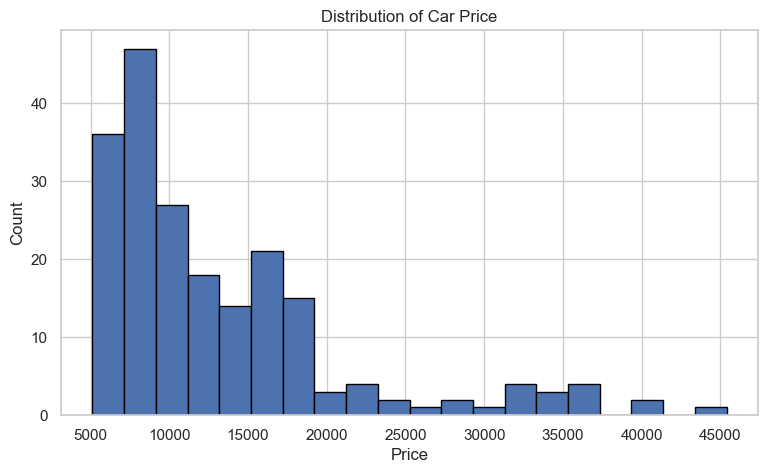

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(car["price"], bins=20, edgecolor="black")
plt.title("Distribution of Car Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

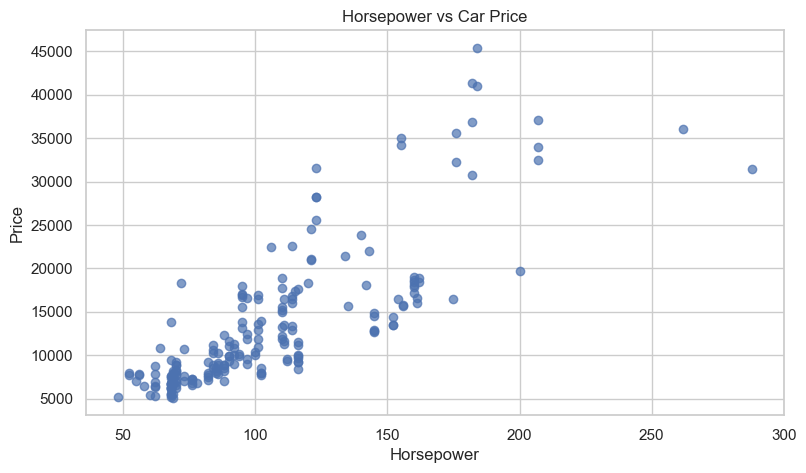

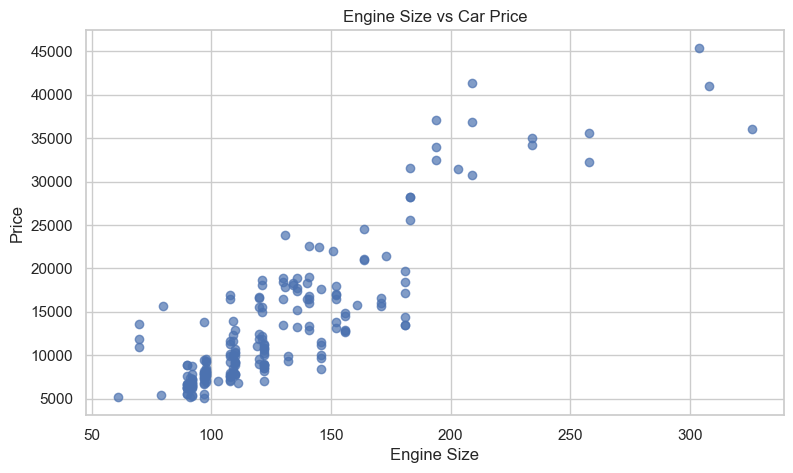

In [9]:
plt.figure(figsize=(9, 5))
plt.scatter(car["horsepower"], car["price"], alpha=0.7)
plt.title("Horsepower vs Car Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(car["enginesize"], car["price"], alpha=0.7)
plt.title("Engine Size vs Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

In [10]:
brand_analysis = (
    car.assign(car_brand=car["CarName"].str.split().str[0].str.lower())
       .groupby("car_brand")["price"]
       .agg(["count", "mean", "median"])
       .sort_values("mean", ascending=False)
)

display(brand_analysis.head(15))

,count,mean,median
car_brand,,,
jaguar,3,34600.000000,35550.00
buick,8,33647.000000,32892.00
porcshce,1,32528.000000,32528.00
porsche,4,31118.625000,32714.25
bmw,8,26118.750000,22835.00
volvo,11,18063.181818,18420.00
audi,7,17859.166714,17710.00
mercury,1,16503.000000,16503.00
toyouta,1,15750.000000,15750.00


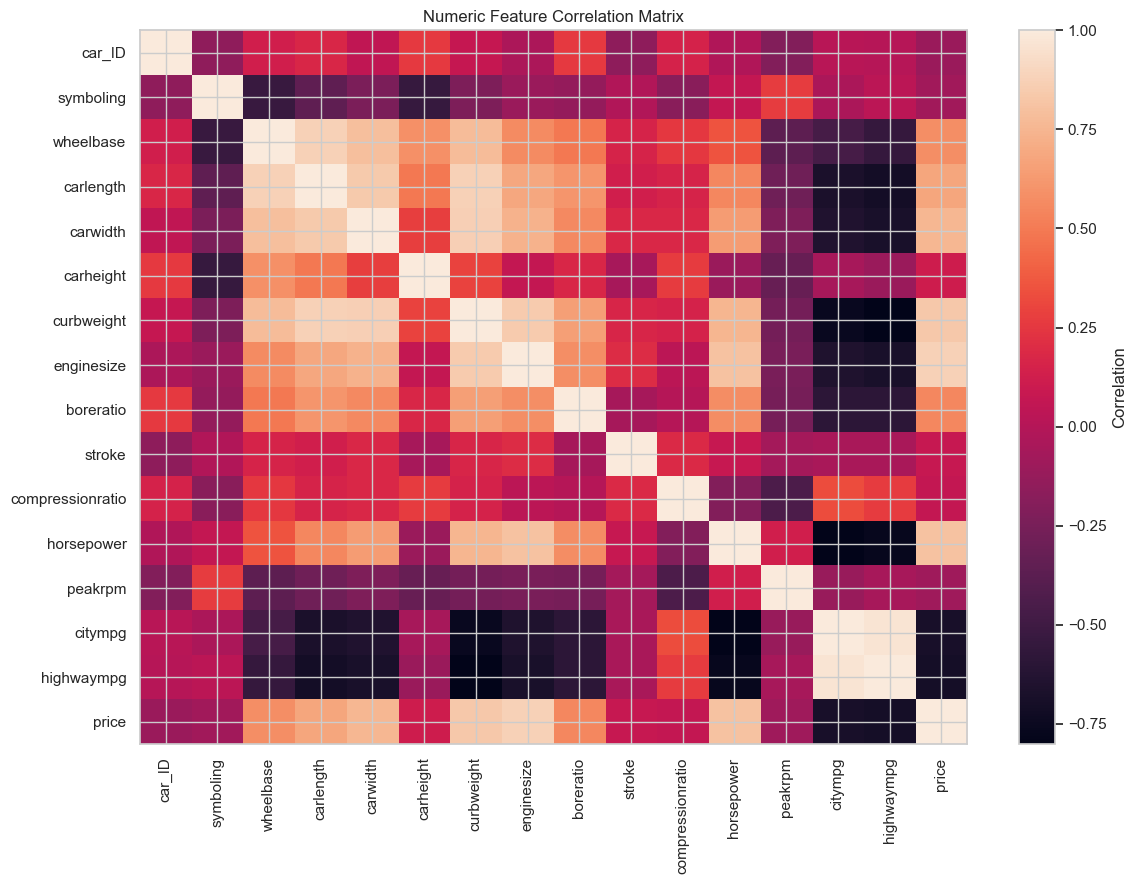

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
Name: price, dtype: float64

In [11]:
numeric_corr = car.select_dtypes(include=np.number).corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(numeric_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_corr.columns)), numeric_corr.columns, rotation=90)
plt.yticks(range(len(numeric_corr.index)), numeric_corr.index)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

display(numeric_corr["price"].sort_values(ascending=False).head(12))

## 7. Train/Test Split with Stratified Price Bins

For a regression problem there is no native `stratify=y`. To keep low-, mid-, and high-priced cars represented in both sets, we create temporary quantile bins **only for splitting** and remove them afterward.

In [12]:
price_bins = pd.qcut(y, q=5, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_bins
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nPrice mean:")
print("Train:", round(y_train.mean(), 2))
print("Test :", round(y_test.mean(), 2))

Train shape: (164, 28)
Test shape : (41, 28)

Price mean:
Train: 13323.09
Test : 13091.2


## 8. Preprocessing Pipeline

In [13]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 18
Categorical features: 10


In [14]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }

## 9. Baseline and Model Comparison

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

results = []
predictions = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    predictions[name] = pred

    metrics = regression_metrics(y_test, pred)
    results.append({"Model": name, **metrics})

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

,Model,MAE,RMSE,R2
0,Linear Regression,1482.213557,2022.155306,0.923570
1,Ridge Regression,1595.529601,2090.646939,0.918305
2,Extra Trees,1597.512661,2093.673105,0.918068
3,Gradient Boosting,1607.597026,2122.579462,0.915790
4,Random Forest,1656.751215,2229.960253,0.907054


## 10. Cross-Validation

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, pipe in pipelines.items():
    scores = -cross_val_score(
        pipe, X, y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    cv_rows.append({
        "Model": name,
        "CV RMSE Mean": scores.mean(),
        "CV RMSE Std": scores.std()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV RMSE Mean")
display(cv_results)

,Model,CV RMSE Mean,CV RMSE Std
2,Random Forest,2037.844696,179.466259
3,Gradient Boosting,2066.659327,170.364178
4,Extra Trees,2205.018979,171.644983
0,Linear Regression,2678.237675,235.137883
1,Ridge Regression,2723.367637,395.942781


## 11. Hyperparameter Tuning

In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8]
}

rf_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV RMSE:", round(-rf_search.best_score_, 2))

Best Random Forest parameters:
{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Best CV RMSE: 2127.1


In [18]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_grid = {
    "model__alpha": [0.1, 1, 10, 50, 100]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_search.best_params_)
print("Best CV RMSE:", round(-ridge_search.best_score_, 2))

Best Ridge alpha: {'model__alpha': 1}
Best CV RMSE: 2964.27


## 12. Final Model Evaluation

In [19]:
tuned_models = {
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned Ridge": ridge_search.best_estimator_
}

final_rows = []
final_predictions = {}

for name, pipe in tuned_models.items():
    pred = pipe.predict(X_test)
    final_predictions[name] = pred
    final_rows.append({"Model": name, **regression_metrics(y_test, pred)})

final_results = pd.DataFrame(final_rows).sort_values("RMSE")
display(final_results)

,Model,MAE,RMSE,R2
1,Tuned Ridge,1322.710674,1689.957857,0.946619
0,Tuned Random Forest,1639.720053,2176.737199,0.911438


## 13. Actual vs Predicted

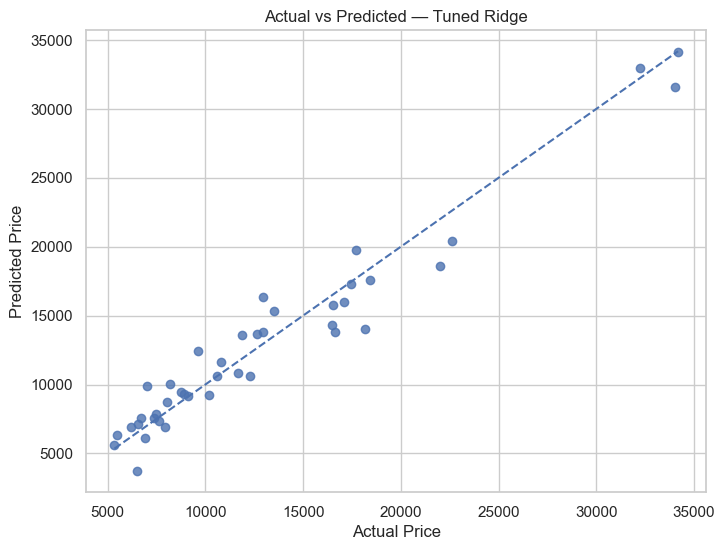

In [20]:
best_name = final_results.iloc[0]["Model"]
best_pipe = tuned_models[best_name]
best_pred = final_predictions[best_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted — {best_name}")
plt.show()

## 14. Residual Analysis

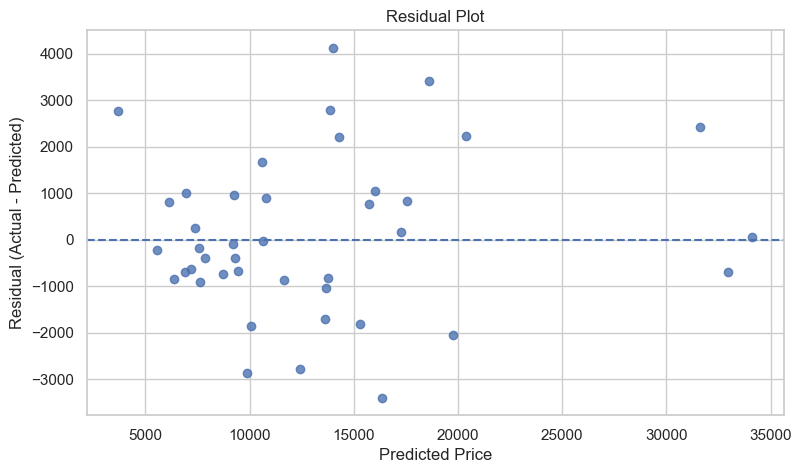

In [21]:
residuals = y_test - best_pred

plt.figure(figsize=(9, 5))
plt.scatter(best_pred, residuals, alpha=0.8)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

## 15. Feature Importance

,Permutation Importance
engine_power_index,2455.123549
car_brand,1008.612855
enginesize,998.251845
curbweight,953.429807
carwidth,874.903361
enginelocation,692.179582
enginetype,569.777015
power_to_weight,506.160477
wheelbase,451.568692
cylindernumber,425.306930


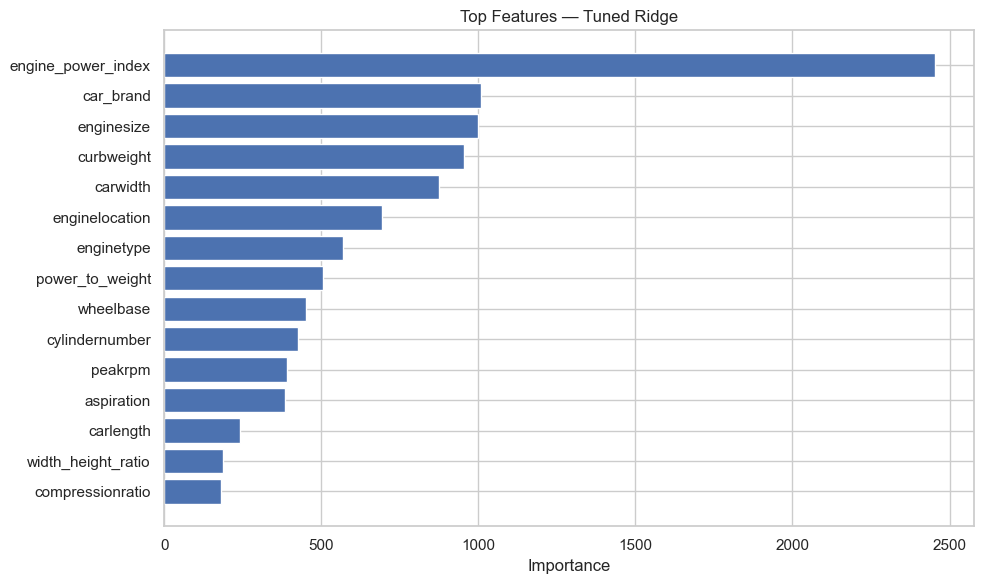

In [22]:
perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance = (
    pd.Series(perm.importances_mean, index=X_test.columns)
      .sort_values(ascending=False)
      .head(15)
)

display(importance.to_frame("Permutation Importance"))

plt.figure(figsize=(10, 6))
plt.barh(importance.sort_values().index, importance.sort_values().values)
plt.title(f"Top Features — {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 16. Example Prediction

In [23]:
sample_input = X_test.iloc[[0]].copy()
sample_actual = y_test.iloc[0]

sample_prediction = best_pipe.predict(sample_input)[0]

print("Actual price    :", round(float(sample_actual), 2))
print("Predicted price :", round(float(sample_prediction), 2))
print("Absolute error  :", round(abs(float(sample_actual - sample_prediction)), 2))

Actual price    : 7395.0
Predicted price : 7575.47
Absolute error  : 180.47


## 17. Final Conclusion

This notebook implements a reproducible regression workflow:

1. Understand and validate the raw data.
2. Engineer a compact `car_brand` feature from `CarName` and add domain-inspired numeric ratios.
3. Preserve the target distribution using stratified price bins during the train/test split.
4. Impute, scale, and one-hot encode inside a single `ColumnTransformer` pipeline.
5. Compare multiple regression algorithms with MAE, RMSE, and R².
6. Use 5-fold cross-validation to check robustness.
7. Tune Random Forest and Ridge using `GridSearchCV`.
8. Evaluate the final models on untouched test data.
9. Inspect predictions, residuals, and permutation importance.

The exact winning model should be taken from the executed `final_results` table rather than assumed in advance.